# Project 3 — Actuator Disk Model for UAV Wind Sensor Placement

Incompressible Navier-Stokes solver with an **actuator-disk body force**:
- **Fractional Step (Projection) Method** — extends Project 2 solver
- **Staggered MAC grid** (pressure at cell centers, velocities at faces)
- **Crank-Nicolson** for viscous terms, **Adams-Bashforth** for advection
- **Actuator disk**: thin column of u-face body force modeling rotor thrust
- Validation against Froude-Rankine momentum theory

## Imports

In [17]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse.linalg import cg, LinearOperator

# Reuse all spatial operators from Project 2 without modification
sys.path.insert(0, os.path.join('..', 'project_2'))
import operators as ops

%load_ext autoreload
%autoreload 2

import actuator_disk as ad

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Parameters

Domain: **8D × 4D** with square cells (D = 1 disk diameter, v_h = 1 induced velocity).
Disk at x = 2D (2 diameters from left wall), centered vertically, spanning y ∈ [1.5, 2.5].

In [18]:
# --- Physical parameters ---
Re    = 200          # Reynolds number: Re = v_h * D / nu
C_T   = 4.0          # Thrust coefficient (Froude-Rankine ideal hover)
v_h   = 1.0          # Induced velocity scale (non-dim = 1)
D     = 1.0          # Disk diameter (length scale)
visc  = v_h * D / Re # kinematic viscosity

# --- Domain ---
xL, xR = 0.0, 8.0   # 8D wide
yB, yT = 0.0, 4.0   # 4D tall
Lx = xR - xL
Ly = yT - yB

# --- Disk geometry ---
x_disk  = 2.0        # disk x-position (2D from left wall)
y_lo    = 1.5        # disk lower edge (centered: y_center = 2.0, D = 1)
y_hi    = 2.5        # disk upper edge

# --- Grid (square cells: dx = dy = delta) ---
ny     = 64
delta  = Ly / ny     # cell size = 4/64 = 0.0625
nx     = int(round(Lx / delta))  # = 128
dx = dy = delta

# --- DOFs ---
n_cells = nx * ny
n_vel   = ny * (nx - 1) + nx * (ny - 1)

# --- Time stepping ---
# The actuator disk drives the far-wake velocity to ~2*v_h.  The AB2 scheme
# requires CFL = u_max * dt / delta <= 0.5, so dt must be sized against 2*v_h.
CFL      = 0.5
dt_adv   = CFL * delta / (2.0 * v_h)   # stable up to u_max = 2*v_h
dt_diff  = delta**2 * Re / 2.0          # diffusion stability limit
dt       = min(dt_adv, dt_diff)
end_time = 10
max_step = int(end_time / dt)

print(f'Grid: nx={nx}, ny={ny},  delta={delta:.5f}')
print(f'dt={dt:.6f},  max_step={max_step},  end_time={end_time:.1f}')
print(f'Re={Re},  visc={visc:.5f},  C_T={C_T}')

Grid: nx=128, ny=64,  delta=0.06250
dt=0.015625,  max_step=640,  end_time=10.0
Re=200,  visc=0.00500,  C_T=4.0


## Grid Indexing

Pointer arrays map 2D indices `(i, j)` to flat 1D array indices (copied from Project 2):
- `ip[i, j]` — pressure cell center, `i=0..nx-1`, `j=0..ny-1`
- `iu[i, j]` — u-face between columns `i-1` and `i`, `i=1..nx-1`
  - Physical location: `x = xL + i*delta`, `y = yB + (j+0.5)*delta`
- `iv[i, j]` — v-face between rows `j-1` and `j`, `j=1..ny-1`

In [19]:
def func_gen_pointer(nx, ny):
    ip = np.full((nx, ny), -1, dtype=int)
    count = 0
    for i in range(nx):
        for j in range(ny):
            ip[i, j] = count
            count += 1

    iu = np.full((nx + 1, ny), -1, dtype=int)
    count = 0
    for i in range(1, nx):
        for j in range(ny):
            iu[i, j] = count
            count += 1

    iv = np.full((nx, ny + 1), -1, dtype=int)
    count = ny * (nx - 1)
    for i in range(nx):
        for j in range(1, ny):
            iv[i, j] = count
            count += 1

    return ip, iu, iv


ip, iu, iv = func_gen_pointer(nx, ny)
print(f'ip range: [{ip.min()}, {ip.max()}]')
print(f'iu DOFs: {(iu >= 0).sum()}  (expected {ny*(nx-1)})')
print(f'iv DOFs: {(iv >= 0).sum()}  (expected {nx*(ny-1)})')

ip range: [0, 8191]
iu DOFs: 8128  (expected 8128)
iv DOFs: 8064  (expected 8064)


## Grid Generation

In [20]:
def func_gen_grid(nx, ny, xL, xR, yB, yT, dx, dy):
    xp = np.linspace(xL + dx / 2, xR - dx / 2, nx)
    yp = np.linspace(yB + dy / 2, yT - dy / 2, ny)
    xu = np.linspace(xL + dx, xR - dx, nx - 1)
    yu = yp.copy()
    xv = xp.copy()
    yv = np.linspace(yB + dy, yT - dy, ny - 1)
    return xp, yp, xu, yu, xv, yv


xp, yp, xu, yu, xv, yv = func_gen_grid(nx, ny, xL, xR, yB, yT, dx, dy)
print(f'xp: [{xp[0]:.4f}, {xp[-1]:.4f}]')
print(f'yp: [{yp[0]:.4f}, {yp[-1]:.4f}]')
print(f'xu: [{xu[0]:.4f}, {xu[-1]:.4f}]  (u-face x-coords)')

xp: [0.0312, 7.9688]
yp: [0.0312, 3.9688]
xu: [0.0625, 7.9375]  (u-face x-coords)


## Boundary Conditions

All walls are **quiescent** (zero velocity). The rotor thrust is provided entirely by the body force — no lid motion.

In [21]:
# All walls at rest (quiescent background)
uBC_T = np.zeros(nx - 1)
uBC_B = np.zeros(nx - 1)
uBC_L = np.zeros(ny)
uBC_R = np.zeros(ny)

vBC_T = np.zeros(nx)
vBC_B = np.zeros(nx)
vBC_L = np.zeros(ny - 1)
vBC_R = np.zeros(ny - 1)

## Actuator Disk Body Force

The rotor is modeled as a thin column of u-faces at `x = x_disk`, spanning the disk diameter.
Force per unit volume (non-dim): $f = C_T / (2\Delta)$, so that
$$\int_\text{disk} f\,dA = \frac{C_T}{2} = T \quad (\rho=v_h=D=1)$$
Froude-Rankine theory gives $C_T = 4$ for ideal hover.

In [22]:
f_disk, i_disk, j_lo, j_hi = ad.disk_force(
    C_T, iu, delta, nx, ny, n_vel, xL, yB, x_disk, y_lo, y_hi
)

T_check = ad.check_thrust(f_disk, delta)
print(f'Disk column: i_disk={i_disk}  (x={xL + i_disk*delta:.4f})')
print(f'Disk rows:   j_lo={j_lo} -> j_hi={j_hi}  ({j_hi - j_lo + 1} cells, D/delta={D/delta:.0f})')
print(f'Thrust integral = {T_check:.6f}  (expected C_T/2 = {C_T/2:.1f})')

Disk column: i_disk=32  (x=2.0000)
Disk rows:   j_lo=24 -> j_hi=39  (16 cells, D/delta=16)
Thrust integral = 2.000000  (expected C_T/2 = 2.0)


## Initialization

Start from rest, or reload a saved solution.

In [23]:
results_dir = 'results'
os.makedirs(results_dir, exist_ok=True)
fname = os.path.join(results_dir, f'Re{int(Re)}_ny{ny}.npz')

Init_Soln = True   # set False to reload previous run

if Init_Soln or not os.path.exists(fname):
    P    = np.zeros(n_cells)
    U    = np.zeros(n_vel)
    time = 0.0
    step = 0
else:
    data = np.load(fname)
    P, U = data['P'], data['U']
    time = float(data['time'])
    step = int(data['step'])
    print(f'Loaded {fname}: t={time:.4f}, step={step}')

## Discrete Operators

All operators imported from `project_2/operators.py` without modification.
Composite operators and CG infrastructure are identical to Project 2.

| Symbol | Expression | Role |
|--------|-----------|------|
| `S` | `I + dt/2·ν·L` | Explicit viscous half-step |
| `R` | `I - dt/2·ν·L` | Implicit viscous half-step (LHS of Step 1) |
| `T` | `D·S·G` | Pressure Poisson operator |
| `C` | `S·G` | Velocity correction (Step 3) |

In [24]:
def laplace_x(x):
    return ops.L(x, delta, iu, iv, nx, ny, n_vel)


def bc_laplace():
    return ops.bc_L(uBC_L, uBC_R, uBC_B, uBC_T,
                    vBC_L, vBC_R, vBC_B, vBC_T,
                    delta, iu, iv, nx, ny, n_vel)


def bc_div():
    return ops.bc_D(uBC_L, uBC_R, vBC_B, vBC_T,
                    delta, ip, nx, ny, n_cells)


def opt_D(x):
    return ops.D(x, delta, ip, iu, iv, nx, ny, n_cells)


def opt_G(x):
    return ops.G(x, delta, ip, iu, iv, nx, ny, n_vel)


def adv(vel):
    return ops.A(vel,
                 uBC_L, uBC_R, uBC_B, uBC_T,
                 vBC_L, vBC_R, vBC_B, vBC_T,
                 delta, iu, iv, nx, ny, n_vel)


def cg_solve(op, b, tol=1e-8):
    A_op = LinearOperator((len(b), len(b)), matvec=op, dtype=np.float64)
    x, info = cg(A_op, b, rtol=tol)
    if info != 0:
        print(f'  CG warning: info={info}')
    return x


def pin_pressure(x):
    y = x.copy()
    y[ip[0, 0]] = 0.0
    return y


def opt_S(x):
    return x + (dt / 2.0 * visc) * laplace_x(x)


def opt_R(x):
    return x - (dt / 2.0 * visc) * laplace_x(x)


def opt_T(x):
    return pin_pressure(opt_D(opt_S(opt_G(x))))


def opt_C(x):
    return opt_S(opt_G(x))

## Time Loop — Fractional Step with Body Force

**Step 1** — Intermediate velocity (body force added to RHS):
$$R\,U^* = S\,U^n + \Delta t\left(\tfrac{3}{2}N^n - \tfrac{1}{2}N^{n-1}\right) + \Delta t\,\nu\,\mathrm{BC}_L + \Delta t\,\mathbf{f}$$

**Step 2** — Pressure Poisson: $T\,P = \frac{1}{\Delta t}(D\,U^* + \mathrm{BC}_D)$

**Step 3** — Velocity correction: $U^{n+1} = U^* - \Delta t\,C\,P$

In [25]:
adv_prev = np.zeros(n_vel)

while time < end_time:
    step += 1
    time += dt

    adv0 = adv(U)
    adv1 = adv_prev

    # Step 1: intermediate velocity (body force f_disk injected here)
    RHS_U = (opt_S(U)
             + dt * (1.5 * adv0 - 0.5 * adv1)
             + dt * visc * bc_laplace()
             + dt * f_disk)
    UF = cg_solve(opt_R, RHS_U, tol=1e-8)

    # Step 2: pressure Poisson
    RHS_P = opt_D(UF) / dt + bc_div() / dt
    RHS_P[ip[0, 0]] = 0.0
    P = cg_solve(opt_T, RHS_P, tol=1e-8)

    # Step 3: velocity correction
    U = UF - dt * opt_C(P)

    adv_prev = adv0

    print(f'\r  step {step:5d}/{max_step}  t={time:.3f}  ||U||={np.linalg.norm(U):.4e}',
          end='', flush=True)

print()  # newline after loop completes
np.savez(fname, P=P, U=U, time=time, step=step, Re=Re, ny=ny)
print(f'Saved to {fname}')

  step   640/640  t=10.000  ||U||=8.0003e+01
Saved to results/Re200_ny64.npz


## Post-Processing

In [31]:
u_2d, v_2d, p_2d = ad.extract_fields(U, P, ip, iu, iv, nx, ny)

j_center = int(round((0.5 * (y_lo + y_hi) - yB) / delta - 0.5))
print(f'Disk centerline: j_center={j_center},  y={yB + (j_center + 0.5)*delta:.4f}')

# Streamwise centerline: u vs x at y = disk center
u_centerline = u_2d[:, j_center]
print(f'u at disk plane (x={x_disk}): {u_centerline[i_disk - 1]:.4f}  (theory v_h=1.0)')
print(f'u at x=x_disk+1D:             {u_centerline[i_disk - 1 + int(D/delta)]:.4f}  (theory 2*v_h=2.0)')

Disk centerline: j_center=32,  y=2.0312
u at disk plane (x=2.0): 0.7920  (theory v_h=1.0)
u at x=x_disk+1D:             -0.6157  (theory 2*v_h=2.0)


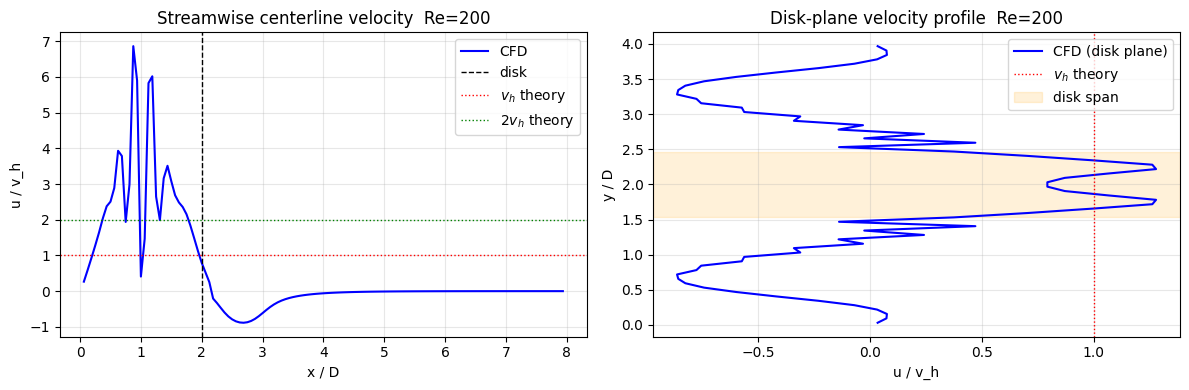

In [32]:
fig = ad.plot_centerline(xu, xv, yp, u_2d, v_2d,
                         x_disk, j_center, i_disk, j_lo, j_hi, Re)
fig.savefig(os.path.join(results_dir, f'centerline_Re{int(Re)}_ny{ny}.png'),
            dpi=150, bbox_inches='tight')
plt.show()

In [33]:
# Thrust validation: integrate momentum flux downstream
i_check = i_disk + int(D / delta)
T_mom   = delta * np.sum(u_2d[i_check, j_lo:j_hi + 1] ** 2)
print(f'Prescribed thrust T = C_T/2 = {C_T/2:.4f}')
print(f'Momentum flux at x = x_disk+D: T_mom = {T_mom:.4f}')

Prescribed thrust T = C_T/2 = 2.0000
Momentum flux at x = x_disk+D: T_mom = 0.1179


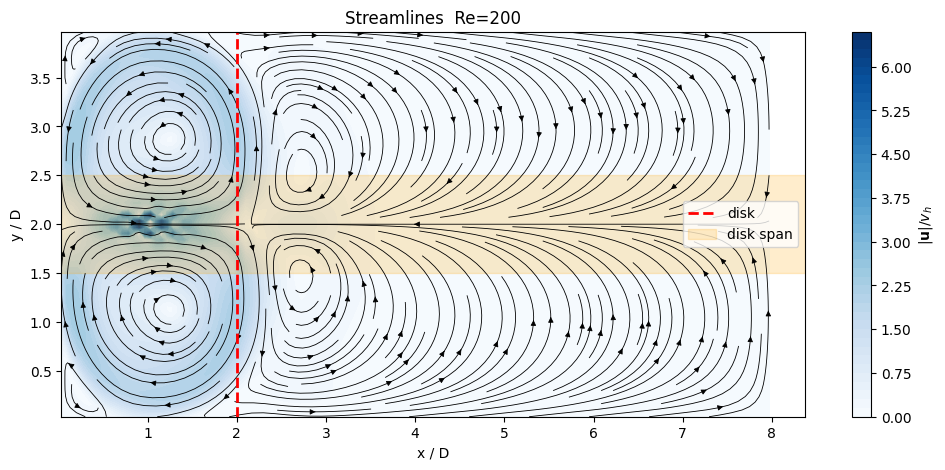

In [41]:
fig = ad.plot_streamlines(xp, yp, xu, yv, u_2d, v_2d, x_disk, y_lo, y_hi, Re)
fig.savefig(os.path.join(results_dir, f'streamlines_Re{int(Re)}_ny{ny}.png'),
            dpi=150, bbox_inches='tight')
plt.show()

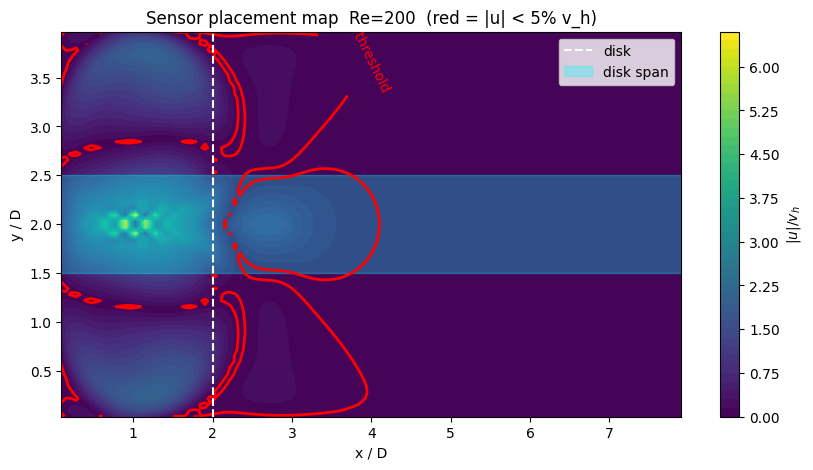

In [35]:
fig = ad.plot_sensor_placement(xp, yp, u_2d, v_2d, xu, yv,
                               x_disk, y_lo, y_hi, Re, threshold=0.05)
fig.savefig(os.path.join(results_dir, f'sensor_Re{int(Re)}_ny{ny}.png'),
            dpi=150, bbox_inches='tight')
plt.show()

## Grid Convergence Study

Sweep $n_y \in \{8, 16, 32, 64\}$ (with $n_x = 2 n_y$ for square cells on the 8×4 domain).
Each run advances to $t = 10$. The finest grid ($n_y = 64$, already computed above) is the
reference; the L² error in the disk-plane centerline $u$-profile is plotted against $\Delta$.

In [36]:
def run_solver(ny_run, Re_run=200, t_end=10.0, C_T_run=4.0):
    """Run actuator-disk solver and return disk-plane u-profile."""
    delta_r = Ly / ny_run
    nx_r    = int(round(Lx / delta_r))
    n_c     = nx_r * ny_run
    n_v     = ny_run * (nx_r - 1) + nx_r * (ny_run - 1)
    dx_r = dy_r = delta_r

    ip_r, iu_r, iv_r = func_gen_pointer(nx_r, ny_run)
    _, yp_r, _, _, _, _ = func_gen_grid(nx_r, ny_run, xL, xR, yB, yT, dx_r, dy_r)

    uBC_T_r = np.zeros(nx_r - 1); uBC_B_r = np.zeros(nx_r - 1)
    uBC_L_r = np.zeros(ny_run);   uBC_R_r = np.zeros(ny_run)
    vBC_T_r = np.zeros(nx_r);     vBC_B_r = np.zeros(nx_r)
    vBC_L_r = np.zeros(ny_run-1); vBC_R_r = np.zeros(ny_run-1)

    f_r, id_r, _, _ = ad.disk_force(
        C_T_run, iu_r, delta_r, nx_r, ny_run, n_v, xL, yB, x_disk, y_lo, y_hi)

    visc_r = v_h * D / Re_run
    dt_r   = min(CFL * delta_r / (2.0 * v_h), delta_r**2 * Re_run / 2.0)
    n_step = int(t_end / dt_r)

    P_r = np.zeros(n_c); U_r = np.zeros(n_v); adv_p = np.zeros(n_v)

    def Lx_r(x): return ops.L(x, delta_r, iu_r, iv_r, nx_r, ny_run, n_v)
    def bcL_r(): return ops.bc_L(uBC_L_r,uBC_R_r,uBC_B_r,uBC_T_r,
                                  vBC_L_r,vBC_R_r,vBC_B_r,vBC_T_r,
                                  delta_r,iu_r,iv_r,nx_r,ny_run,n_v)
    def bcD_r(): return ops.bc_D(uBC_L_r,uBC_R_r,vBC_B_r,vBC_T_r,
                                  delta_r,ip_r,nx_r,ny_run,n_c)
    def oD(x):   return ops.D(x,delta_r,ip_r,iu_r,iv_r,nx_r,ny_run,n_c)
    def oG(x):   return ops.G(x,delta_r,ip_r,iu_r,iv_r,nx_r,ny_run,n_v)
    def oAdv(v): return ops.A(v,uBC_L_r,uBC_R_r,uBC_B_r,uBC_T_r,
                                vBC_L_r,vBC_R_r,vBC_B_r,vBC_T_r,
                                delta_r,iu_r,iv_r,nx_r,ny_run,n_v)
    def oS(x):  return x + (dt_r/2*visc_r)*Lx_r(x)
    def oR(x):  return x - (dt_r/2*visc_r)*Lx_r(x)
    def oT(x):
        y = oD(oS(oG(x))); y[ip_r[0,0]] = 0.0; return y
    def oC(x):  return oS(oG(x))
    def cg_r(op, b):
        Aop = LinearOperator((len(b),len(b)), matvec=op, dtype=np.float64)
        x, _ = cg(Aop, b, rtol=1e-8); return x

    for s in range(1, n_step + 1):
        a0 = oAdv(U_r)
        RHS_U = oS(U_r) + dt_r*(1.5*a0 - 0.5*adv_p) + dt_r*visc_r*bcL_r() + dt_r*f_r
        UF_r  = cg_r(oR, RHS_U)
        RHS_P = oD(UF_r)/dt_r + bcD_r()/dt_r; RHS_P[ip_r[0,0]] = 0.0
        P_r   = cg_r(oT, RHS_P)
        U_r   = UF_r - dt_r * oC(P_r)
        adv_p = a0
        print(f'\r    step {s:5d}/{n_step}', end='', flush=True)
    print()  # newline after inner loop

    u2d_r = U_r[iu_r[1:nx_r, :ny_run]]
    return u2d_r[id_r - 1, :], yp_r, delta_r


grid_sizes = [8, 16, 32, 64]
results_conv = {}
for ny_r in grid_sizes:
    delta_r = Ly / ny_r
    dt_r    = min(CFL * delta_r / (2.0 * v_h), delta_r**2 * Re / 2.0)
    n_steps_r = int(10.0 / dt_r)
    print(f'ny={ny_r:3d}  ({n_steps_r} steps):', flush=True)
    u_prof, yp_r, delta_r = run_solver(ny_r, t_end=10.0)
    results_conv[ny_r] = (u_prof, yp_r, delta_r)
    print(f'  u_center={u_prof[len(u_prof)//2]:.4f}')

ny=  8  (80 steps):
    step    80/80
  u_center=2.3008
ny= 16  (160 steps):
    step   160/160
  u_center=1.8175
ny= 32  (320 steps):
    step   320/320
  u_center=0.9404
ny= 64  (640 steps):
    step   640/640
  u_center=0.7920


ny=  8  delta=0.50000  L2_err=1.3357e+00
ny= 16  delta=0.25000  L2_err=1.0375e+00
ny= 32  delta=0.12500  L2_err=1.7974e-01


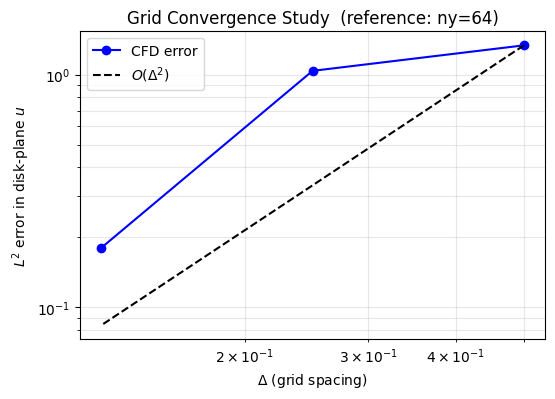

In [37]:
# Reference: finest grid run above (ny=64)
u_ref, yp_ref, _ = results_conv[64]

deltas = []; errors = []
for ny_r in [8, 16, 32]:
    u_c, yp_c, delta_r = results_conv[ny_r]
    u_ref_interp = np.interp(yp_c, yp_ref, u_ref)
    err = np.sqrt(np.mean((u_c - u_ref_interp)**2))
    deltas.append(delta_r)
    errors.append(err)
    print(f'ny={ny_r:3d}  delta={delta_r:.5f}  L2_err={err:.4e}')

fig, ax = plt.subplots(figsize=(6, 4))
ax.loglog(deltas, errors, 'bo-', label='CFD error')
d_ref = np.array([deltas[0], deltas[-1]])
ax.loglog(d_ref, errors[0]*(d_ref/deltas[0])**2, 'k--', label=r'$O(\Delta^2)$')
ax.set_xlabel(r'$\Delta$ (grid spacing)')
ax.set_ylabel(r'$L^2$ error in disk-plane $u$')
ax.set_title('Grid Convergence Study  (reference: ny=64)')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
fig.savefig(os.path.join(results_dir, 'convergence.png'), dpi=150, bbox_inches='tight')
plt.show()

## Reynolds Number Sweep

Run $Re \in \{100, 200, 500, 1000\}$ on the baseline grid ($n_y = 64$).
Compare centerline wake profiles to assess the influence of viscosity on wake development.

In [38]:
Re_list = [100, 200, 500, 1000]
wake_profiles = {}
yp_sweep = None

for Re_r in Re_list:
    delta_64 = Ly / 64
    dt_r     = min(CFL * delta_64 / (2.0 * v_h), delta_64**2 * Re_r / 2.0)
    n_steps_r = int(10.0 / dt_r)
    print(f'Re={Re_r}  ({n_steps_r} steps):', flush=True)
    u_prof, yp_r, _ = run_solver(64, Re_run=Re_r, t_end=10.0)
    wake_profiles[Re_r] = u_prof
    yp_sweep = yp_r
    print(f'  u_center={u_prof[len(u_prof)//2]:.4f}')

fig, ax = plt.subplots(figsize=(6, 5))
for Re_r, u_p in wake_profiles.items():
    ax.plot(u_p, yp_sweep, label=f'Re={Re_r}')
ax.axvline(1.0, color='k', linestyle='--', linewidth=1, label=r'$v_h$ theory')
ax.axhspan(y_lo, y_hi, alpha=0.15, color='orange', label='disk span')
ax.set_xlabel('u / v_h')
ax.set_ylabel('y / D')
ax.set_title('Disk-plane u-profile for various Re  (t=10)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
fig.savefig(os.path.join(results_dir, 'Re_sweep.png'), dpi=150, bbox_inches='tight')
plt.show()

Re=100  (640 steps):
    step   252/640

KeyboardInterrupt: 